In [15]:
import xarray as xr
import rioxarray as rio
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

In [11]:
landsat_fn_b4 = "/Users/seanfreeman/Downloads/LC09_L2SP_021036_20260222_20260223_02_T1/LC09_L2SP_021036_20260222_20260223_02_T1_SR_B4.TIF"
landsat_fn_b3 = "/Users/seanfreeman/Downloads/LC09_L2SP_021036_20260222_20260223_02_T1/LC09_L2SP_021036_20260222_20260223_02_T1_SR_B3.TIF"
landsat_fn_b2 = "/Users/seanfreeman/Downloads/LC09_L2SP_021036_20260222_20260223_02_T1/LC09_L2SP_021036_20260222_20260223_02_T1_SR_B2.TIF"


In [12]:
landsat_b4 = rio.open_rasterio(landsat_fn_b4)
landsat_b3 = rio.open_rasterio(landsat_fn_b3)
landsat_b2 = rio.open_rasterio(landsat_fn_b2)

In [14]:
landsat_data = {
    'blue': landsat_b2,
    'green': landsat_b3,
    'red': landsat_b4,
}

In [20]:
landsat_data_transformed = {}
for band_name in landsat_data:
    landsat_data_transformed[band_name] = landsat_data[band_name].rio.reproject("EPSG:4326")

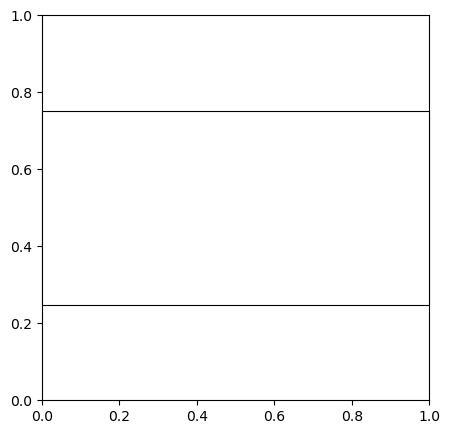

In [ ]:
proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    1, 1,
    figsize=(5, 5),
)
ax_rgb = fig.add_subplot(111, projection=proj)

ax_rgb.set_extent([-90, -80, 30, 40], crs=ccrs.PlateCarree())
rgb = np.dstack([landsat_data['red'], landsat_data['green'], landsat_data['blue']])
ax_rgb.pcolormesh(landsat_data_transformed['red'].x, landsat_data_transformed['red'].y,
    rgb,
    transform=proj,
)


In [ ]:
def normalize(band):
    """Linearly stretch a band to [0, 1]."""
    lo, hi = band.min(), band.max()
    return np.zeros_like(band) if hi == lo else (band - lo) / (hi - lo)

